In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import shutil
import importlib
from dataclasses import fields
import json
from datetime import datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


NB_DIR = Path.cwd()
PROJECT_DIR = NB_DIR.parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import scripts.fieldset as pfs
import scripts.particles as pparticles
import scripts.kernels as pkernels
import scripts.run as prun
import scripts.metrics_clustering as mclus
import scripts.metrics_dispersion as mdisp
import scripts.metrics_patchiness as mpatch
import theme.plot_theme as ptheme

importlib.reload(pfs)
importlib.reload(pparticles)
importlib.reload(pkernels)
importlib.reload(prun)
importlib.reload(mclus)
importlib.reload(mdisp)
importlib.reload(mpatch)
importlib.reload(ptheme)

ptheme.apply_theme()
ptheme.apply_theme()

In [2]:
# ============================================================
# 2. DIRECTORY / CASE SETTINGS
# ============================================================

case_name = "parcels_sea_win_spinupsim_L1"   # edit only this
RUN_TITLE_INFO = case_name

INPUT_DIR = (NB_DIR / "../data/input").resolve()
DATA_FILE = (INPUT_DIR / f"{case_name}.nc").resolve()

if not DATA_FILE.exists():
    available = sorted(p.name for p in INPUT_DIR.glob("*"))
    raise FileNotFoundError(
        f"Could not find input file:\n{DATA_FILE}\n\n"
        f"Available files in {INPUT_DIR}:\n"
        + "\n".join(available)
    )


# ============================================================
# 3. STATISTICS SWITCHES
# Only choose whether each statistic is computed.
# Detailed settings belong in the later statistics notebook.
# ============================================================

COMPUTE_DISPERSION = False
COMPUTE_PAIR_DISPERSION = False
COMPUTE_RDF = False
COMPUTE_VORONOI = True
COMPUTE_PATCHINESS = False
COMPUTE_RESIDENCE_RETENTION = False
COMPUTE_CONDITIONAL_JPDF_STATS = False

STATISTIC_FLAGS = {
    "dispersion": COMPUTE_DISPERSION,
    "pair_dispersion": COMPUTE_PAIR_DISPERSION,
    "rdf": COMPUTE_RDF,
    "voronoi": COMPUTE_VORONOI,
    "patchiness": COMPUTE_PATCHINESS,
    "residence_retention": COMPUTE_RESIDENCE_RETENTION,
    "conditional_jpdf_stats": COMPUTE_CONDITIONAL_JPDF_STATS,
}

COMPUTE_STATISTICS = any(STATISTIC_FLAGS.values())


# ============================================================
# 4. PARCELS ADVECTION SETTINGS
# ============================================================

DAY_PER_INDEX = 3.0 / 24.0
TIME_STEP_SECONDS = int(DAY_PER_INDEX * 86400)

RELEASE_TIME_INDEX = 0
LEVEL_INDICES = (0,)

RUNTIME_MODE = "manual"       # "manual" or "full_forcing"
RUNTIME_DAYS_REQUESTED = 7.0

DT_SECONDS = 300
OUTPUTDT_SECONDS = TIME_STEP_SECONDS

NX = 60
NY = 60

PERIODIC = True
RELEASE_MARGIN_CELLS = 1.0

RUN_ADVECTION = True
OVERWRITE_OUTPUT = True

SAVE_TRAJECTORIES = False
SAVE_METADATA = False
SAVE_FIGURES = False

DELETE_TEMP_TRAJECTORIES_AFTER_LOAD = True


# ============================================================
# 5. PARTICLE CLASS SETTINGS
# ============================================================

# Passive only:
INERTIAL_RELAXATION_TIMES_SECONDS = ()

# Passive + inertial particles:
# INERTIAL_RELAXATION_TIMES_SECONDS = (100.0, 10_000.0)

FLOW_TIMESCALE_SECONDS = 86400.0   # St = tau_p / T_ref
INITIAL_PARTICLE_VELOCITY = "fluid"  # "fluid" or "zero"


def tau_to_tag(tau):
    return f"tau{tau:g}s".replace(".", "p").replace("+", "")


particle_specs = [
    {
        "particle_class": "passive",
        "tau_p_seconds": 0.0,
        "label": "passive",
        "tag": "passive",
    }
]

for tau in INERTIAL_RELAXATION_TIMES_SECONDS:
    st = tau / FLOW_TIMESCALE_SECONDS
    particle_specs.append(
        {
            "particle_class": "inertial",
            "tau_p_seconds": float(tau),
            "label": f"St = {st:g}",
            "tag": f"inertial_{tau_to_tag(tau)}_St{st:g}".replace(".", "p"),
        }
    )

print("Particle classes:")
for spec in particle_specs:
    print(f"  {spec['tag']} | {spec['label']} | tau_p = {spec['tau_p_seconds']} s")


# ============================================================
# 6. OUTPUT ORGANIZATION
# results/<case_name>/...
# ============================================================

release_time_days = RELEASE_TIME_INDEX * DAY_PER_INDEX
level_tag = "k" + "-".join(str(k) for k in LEVEL_INDICES)

if len(INERTIAL_RELAXATION_TIMES_SECONDS) == 0:
    particle_collection_tag = "passive"
else:
    particle_collection_tag = "passive_plus_inertial"

run_collection_id = f"{particle_collection_tag}_{level_tag}_release_t{RELEASE_TIME_INDEX:04d}"

CASE_RESULTS_DIR = (NB_DIR / f"../results/{case_name}").resolve()
CASE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAJ_DIR = CASE_RESULTS_DIR / "trajectories"
TMP_TRAJ_DIR = CASE_RESULTS_DIR / "_tmp" / "trajectories"
METADATA_DIR = CASE_RESULTS_DIR / "metadata"
METRICS_DIR = CASE_RESULTS_DIR / "metrics"
FIG_DIR = CASE_RESULTS_DIR / "figures" / "trajectory_snapshots"

RUN_OUT_DIR = TRAJ_DIR if SAVE_TRAJECTORIES else TMP_TRAJ_DIR
RUN_OUT_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_METADATA:
    METADATA_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

if COMPUTE_STATISTICS:
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON = METADATA_DIR / f"{run_collection_id}_config.json"

print("\nInput / output")
print(f"  input file        : {DATA_FILE.name}")
print(f"  input dir         : {INPUT_DIR}")
print(f"  case results dir  : {CASE_RESULTS_DIR}")
print(f"  trajectory dir    : {RUN_OUT_DIR}")
print(f"  save trajectories : {SAVE_TRAJECTORIES}")
print(f"  figure dir        : {FIG_DIR}")
print(f"  save figures      : {SAVE_FIGURES}")


# ============================================================
# 7. CHECK RUNCONFIG
# ============================================================

required_runconfig_fields = {
    "time_step_seconds",
    "release_time_index",
    "periodic",
    "level_indices",
    "release_margin_cells",
    "particle_class",
    "tau_p_seconds",
    "flow_timescale_seconds",
    "initial_particle_velocity",
}

available_runconfig_fields = {f.name for f in fields(prun.RunConfig)}
missing = required_runconfig_fields - available_runconfig_fields

if missing:
    raise RuntimeError(
        "RunConfig is missing required fields:\n"
        f"{sorted(missing)}\n\n"
        "Update scripts/run.py, then restart the kernel or reload prun."
    )


# ============================================================
# 8. RAW DATASET QC
# ============================================================

raw_qc = pfs.summarize_dataset(DATA_FILE)

print("\nRaw MITgcm input QC")
print(f"  dims      : {raw_qc.get('dims')}")
print(f"  U dims    : {raw_qc.get('u_dims', 'not reported')}")
print(f"  V dims    : {raw_qc.get('v_dims', 'not reported')}")
print(f"  x center  : {raw_qc.get('x_center', raw_qc.get('x_name', 'unknown'))}")
print(f"  y center  : {raw_qc.get('y_center', raw_qc.get('y_name', 'unknown'))}")
print(f"  U var     : {raw_qc.get('u_name')}")
print(f"  V var     : {raw_qc.get('v_name')}")


# ============================================================
# 9. BUILD FIELDSET + PARCELS-READY QC
# ============================================================

fieldset, meta, ds_parcels = pfs.build_fieldset(
    DATA_FILE,
    surface_only=True,
    mesh="flat",
    level_indices=LEVEL_INDICES,
    time_step_seconds=TIME_STEP_SECONDS,
    periodic=PERIODIC,
)

try:
    qc = pfs.quick_qc_parcels_input(ds_parcels)
except TypeError:
    qc = pfs.quick_qc_parcels_input(ds_parcels, "U", "V")

print("\nParcels-ready field QC")
print(f"  dims      : {qc.get('dims')}")
print(f"  U shape   : {qc.get('U_shape', qc.get('u_shape'))}")
print(f"  V shape   : {qc.get('V_shape', qc.get('v_shape'))}")
print(f"  x range   : {qc.get('x_min'):.1f} to {qc.get('x_max'):.1f} m")
print(f"  y range   : {qc.get('y_min'):.1f} to {qc.get('y_max'):.1f} m")
print(f"  n time    : {qc.get('n_time', ds_parcels.sizes['time'])}")
print(f"  dt head   : {np.diff(ds_parcels['time'].values[:5])}")
print(f"  U NaN t0  : {qc.get('U_nan_fraction_t0', qc.get('u_nan_fraction_t0'))}")
print(f"  V NaN t0  : {qc.get('V_nan_fraction_t0', qc.get('v_nan_fraction_t0'))}")


# ============================================================
# 10. RUNTIME SELECTION
# ============================================================

n_forcing_times = ds_parcels.sizes["time"]
max_runtime_days = (
    (n_forcing_times - 1 - RELEASE_TIME_INDEX)
    * TIME_STEP_SECONDS
    / 86400.0
)

if RUNTIME_MODE == "full_forcing":
    RUNTIME_DAYS = max_runtime_days

elif RUNTIME_MODE == "manual":
    RUNTIME_DAYS = float(RUNTIME_DAYS_REQUESTED)

    if RUNTIME_DAYS > max_runtime_days:
        raise ValueError(
            f"Requested runtime is too long.\n"
            f"Requested runtime : {RUNTIME_DAYS:.3f} days\n"
            f"Available runtime : {max_runtime_days:.3f} days\n"
            f"Use RUNTIME_MODE='full_forcing' or reduce RUNTIME_DAYS_REQUESTED."
        )

else:
    raise ValueError(f"Unknown RUNTIME_MODE: {RUNTIME_MODE}")

print("\nRuntime settings")
print(f"  forcing time steps    : {n_forcing_times}")
print(f"  forcing dt            : {TIME_STEP_SECONDS} s")
print(f"  release index         : {RELEASE_TIME_INDEX}")
print(f"  max available runtime : {max_runtime_days:.3f} days")
print(f"  selected runtime      : {RUNTIME_DAYS:.3f} days")


# ============================================================
# 11. SAVE COLLECTION METADATA
# ============================================================

config_dict = {
    "created_utc": datetime.utcnow().isoformat() + "Z",
    "case_name": case_name,
    "run_collection_id": run_collection_id,
    "input_nc": str(DATA_FILE),
    "case_results_dir": str(CASE_RESULTS_DIR),
    "trajectory_dir": str(RUN_OUT_DIR),
    "release_time_index": int(RELEASE_TIME_INDEX),
    "release_time_days": float(release_time_days),
    "level_indices": list(LEVEL_INDICES),
    "runtime_mode": RUNTIME_MODE,
    "runtime_days": float(RUNTIME_DAYS),
    "dt_seconds": int(DT_SECONDS),
    "outputdt_seconds": int(OUTPUTDT_SECONDS),
    "time_step_seconds": int(TIME_STEP_SECONDS),
    "nx": int(NX),
    "ny": int(NY),
    "periodic": bool(PERIODIC),
    "release_margin_cells": float(RELEASE_MARGIN_CELLS),
    "save_trajectories": bool(SAVE_TRAJECTORIES),
    "particle_specs": particle_specs,
    "statistics_flags": STATISTIC_FLAGS,
}

if SAVE_METADATA:
    with open(CONFIG_JSON, "w") as f:
        json.dump(config_dict, f, indent=2)

    print(f"\nSaved metadata: {CONFIG_JSON}")


# ============================================================
# 12. PARCELS ADVECTION
# One trajectory file per particle class.
# ============================================================

run_outputs = {}

for spec in particle_specs:
    particle_tag = spec["tag"]
    run_id = f"{particle_tag}_{level_tag}_release_t{RELEASE_TIME_INDEX:04d}"
    out_zarr = RUN_OUT_DIR / f"{run_id}.zarr"

    if OVERWRITE_OUTPUT and RUN_ADVECTION and out_zarr.exists():
        if out_zarr.is_dir():
            shutil.rmtree(out_zarr)
        else:
            out_zarr.unlink()

    if RUN_ADVECTION:
        config = prun.RunConfig(
            input_nc=str(DATA_FILE),
            output_path=str(out_zarr),
            runtime_days=RUNTIME_DAYS,
            dt_seconds=DT_SECONDS,
            outputdt_seconds=OUTPUTDT_SECONDS,
            time_step_seconds=TIME_STEP_SECONDS,
            release_time_index=RELEASE_TIME_INDEX,
            surface_only=True,
            mesh="flat",
            periodic=PERIODIC,
            level_indices=LEVEL_INDICES,
            release_mode="grid",
            nx=NX,
            ny=NY,
            release_margin_cells=RELEASE_MARGIN_CELLS,
            particle_class=spec["particle_class"],
            tau_p_seconds=spec["tau_p_seconds"],
            flow_timescale_seconds=FLOW_TIMESCALE_SECONDS,
            initial_particle_velocity=INITIAL_PARTICLE_VELOCITY,
        )

        print(f"\nRunning Parcels advection: {spec['label']}")
        info = prun.run_parcels_experiment(config)

    else:
        if not out_zarr.exists():
            raise FileNotFoundError(
                f"RUN_ADVECTION=False, but trajectory file was not found:\n{out_zarr}"
            )

        print(f"\nSkipping advection, using existing trajectory: {out_zarr}")
        info = {
            "output_path": str(out_zarr),
            "particle_label": spec["label"],
            "particle_class": spec["particle_class"],
            "tau_p_seconds": spec["tau_p_seconds"],
            "stokes_number": (
                np.nan
                if spec["tau_p_seconds"] == 0.0
                else spec["tau_p_seconds"] / FLOW_TIMESCALE_SECONDS
            ),
        }

    run_outputs[particle_tag] = {
        "info": info,
        "path": out_zarr,
        "label": spec["label"],
        "spec": spec,
    }

    print(f"  output path : {out_zarr}")
    print(f"  tau_p       : {spec['tau_p_seconds']} s")
    print(f"  label       : {spec['label']}")

Particle classes:
  passive | passive | tau_p = 0.0 s

Input / output
  input file        : parcels_sea_win_spinupsim_L1.nc
  input dir         : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\data\input
  case results dir  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1
  trajectory dir    : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1\_tmp\trajectories
  save trajectories : False
  figure dir        : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1\figures\trajectory_snapshots
  save figures      : False

Raw MITgcm input QC
  dims      : {'Zmd000001': 1, 'T': 224, 'Y': 512, 'Xp1': 513, 'Yp1': 513, 'X': 512}
  U dims    : ('T', 'Zmd000001', 'Y', 'Xp1')
  V dims    : ('T', 'Zmd000001', 'Yp1', 'X')
  x center  : X
  y center  : Y
  U var     : UVEL
  V var     : VVEL

Parcels-ready field QC
 

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_18268\271977299.py:284: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat() + "Z",
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\ast.py:407: KernelWarning: Don't change the location of a particle directly in a Kernel. Use particle_dlon, particle_dlat, etc.
  return visitor(node)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\parcels\field.py:1184: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()


INFO: Output files are stored in C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1\_tmp\trajectories\passive_k0_release_t0000.zarr.
  0%|          | 0/604800.0 [00:00<?, ?it/s]

c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\parcels\particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\parcels\particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\parcels\particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████| 604800.0/604800.0 [00:34<00:00, 17422.36it/s]
  output path : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1\_tmp\trajectories\passive_k0_release_t0000.zarr
  tau_p       : 0.0 s
  label       : passive



Trajectory QC: passive
  label     : passive
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1\_tmp\trajectories\passive_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 56}
  variables : ['lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_p', 'time', 'z']

Deleted temporary trajectory directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1\_tmp\trajectories


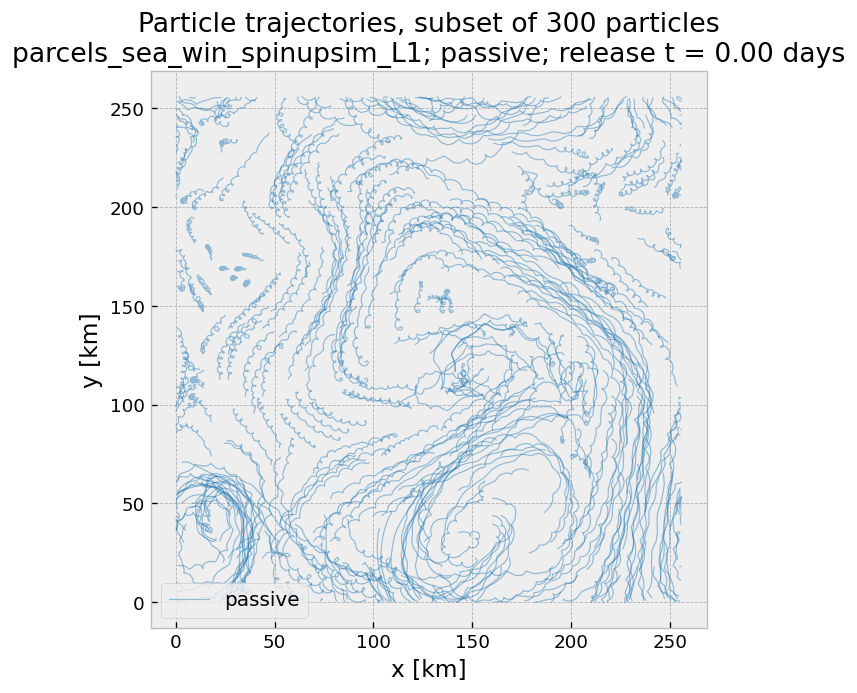

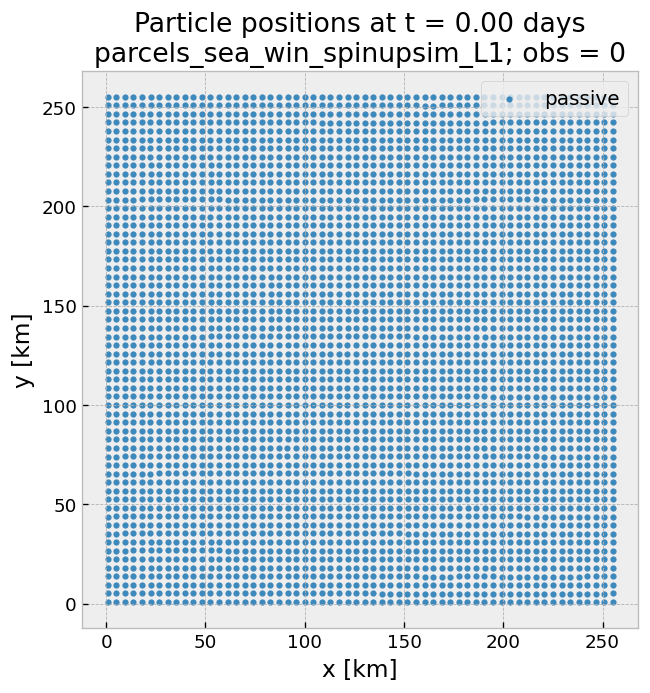

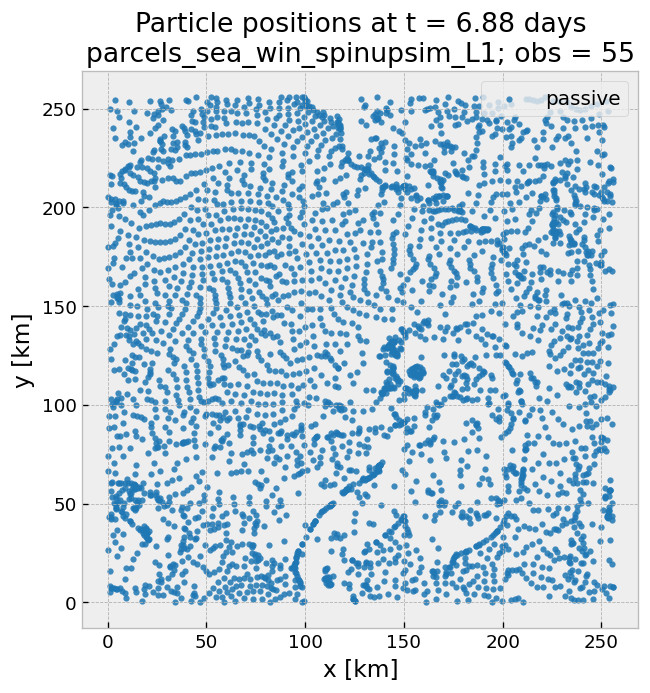


Statistics are switched on, but computation is intentionally not implemented here.
Create a separate statistics notebook/script using the saved trajectory archives.
  metrics dir: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\parcels_sea_win_spinupsim_L1\metrics


In [ ]:
# ============================================================
# 13. LOAD TRAJECTORIES
# ============================================================

if "run_outputs" not in globals():
    raise RuntimeError("run_outputs is not defined. Run the setup/advection cell first.")

trajectories = {}

for particle_tag, item in run_outputs.items():
    ds_traj = prun.load_trajectories(item["path"])

    if not SAVE_TRAJECTORIES:
        ds_traj = ds_traj.load()

    trajectories[particle_tag] = {
        "ds": ds_traj,
        "label": item["label"],
        "path": item["path"],
        "info": item["info"],
        "spec": item["spec"],
    }

    print(f"\nTrajectory QC: {particle_tag}")
    print(f"  label     : {item['label']}")
    print(f"  path      : {item['path']}")
    print(f"  dims      : {dict(ds_traj.sizes)}")
    print(f"  variables : {list(ds_traj.data_vars)}")

if not SAVE_TRAJECTORIES and DELETE_TEMP_TRAJECTORIES_AFTER_LOAD:
    shutil.rmtree(RUN_OUT_DIR, ignore_errors=True)
    print(f"\nDeleted temporary trajectory directory: {RUN_OUT_DIR}")


# ============================================================
# 14. HELPER FUNCTIONS
# ============================================================

def savefig_if_enabled(fig, path, save=True):
    if not save:
        return

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    try:
        ptheme.save_figure(fig, path, save=save)
    except TypeError:
        ptheme.save_figure(fig, path)


def get_xy_names(ds):
    xname = "lon" if "lon" in ds.variables else "x"
    yname = "lat" if "lat" in ds.variables else "y"
    return xname, yname


def get_static_particle_var(ds, varname, obs_index=0):
    if varname not in ds:
        return None

    da = ds[varname]

    if "obs" in da.dims:
        return da.isel(obs=obs_index).values

    return da.values


def get_release_ids(ds):
    release_ids = get_static_particle_var(ds, "release_id", obs_index=0)

    if release_ids is None:
        release_ids = np.arange(ds.sizes["trajectory"], dtype=int)

    return np.asarray(release_ids, dtype=int)


def get_common_release_ids(trajectories):
    common_ids = None

    for item in trajectories.values():
        release_ids = get_release_ids(item["ds"])

        if common_ids is None:
            common_ids = set(release_ids.tolist())
        else:
            common_ids = common_ids.intersection(set(release_ids.tolist()))

    return np.array(sorted(common_ids), dtype=int)


def get_periodic_domain_lengths(ds_parcels):
    xg = np.asarray(ds_parcels["x"].values, dtype=float)
    yg = np.asarray(ds_parcels["y"].values, dtype=float)

    dxg = float(np.nanmedian(np.diff(xg)))
    dyg = float(np.nanmedian(np.diff(yg)))

    x_edge_min = float(xg[0] - 0.5 * dxg)
    x_edge_max = float(xg[-1] + 0.5 * dxg)
    y_edge_min = float(yg[0] - 0.5 * dyg)
    y_edge_max = float(yg[-1] + 0.5 * dyg)

    return x_edge_max - x_edge_min, y_edge_max - y_edge_min


def insert_nan_at_periodic_jumps(x, y, Lx, Ly, jump_fraction=0.5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    xb = []
    yb = []

    for i in range(len(x)):
        if i > 0:
            jump_x = (
                np.isfinite(x[i])
                and np.isfinite(x[i - 1])
                and abs(x[i] - x[i - 1]) > jump_fraction * Lx
            )
            jump_y = (
                np.isfinite(y[i])
                and np.isfinite(y[i - 1])
                and abs(y[i] - y[i - 1]) > jump_fraction * Ly
            )

            if jump_x or jump_y:
                xb.append(np.nan)
                yb.append(np.nan)

        xb.append(x[i])
        yb.append(y[i])

    return np.asarray(xb), np.asarray(yb)


def to_km(a):
    return np.asarray(a, dtype=float) / 1000.0


def resolve_obs_index(selection, n_obs):
    if isinstance(selection, str):
        selection = selection.lower()

        if selection == "first":
            return 0
        if selection == "last":
            return n_obs - 1

        raise ValueError(f"Unknown obs selection string: {selection}")

    selection = int(selection)

    if selection < 0:
        return n_obs + selection

    return selection


def get_elapsed_time_days(ds, obs_index):
    if "time" not in ds:
        return np.nan

    t = ds["time"].isel(trajectory=0, obs=obs_index).values
    t0 = ds["time"].isel(trajectory=0, obs=0).values

    if np.issubdtype(np.asarray(t).dtype, np.datetime64):
        return float((t - t0) / np.timedelta64(1, "s")) / 86400.0

    return float(t - t0) / 86400.0


def build_class_style_map(trajectories):
    particle_tags = list(trajectories.keys())

    cmap = plt.get_cmap(getattr(ptheme, "CLASS_COLORMAP", "tab10"))
    marker_cycle = getattr(
        ptheme,
        "MARKER_CYCLE",
        ("o", "s", "^", "D", "P", "X", "v", "<", ">", "*"),
    )

    style_map = {}

    for i, particle_tag in enumerate(particle_tags):
        item = trajectories[particle_tag]

        style_map[particle_tag] = {
            "label": item["label"],
            "color": cmap(i % cmap.N),
            "marker": marker_cycle[i % len(marker_cycle)],
        }

    return style_map


if len(trajectories) == 0:
    raise RuntimeError("No trajectories were loaded.")

Lx, Ly = get_periodic_domain_lengths(ds_parcels)
class_style_map = build_class_style_map(trajectories)


# ============================================================
# 15. TRAJECTORY / POSITION SNAPSHOT FIGURES
# ============================================================

PLOT_TRAJECTORY_SUBSET_PER_CLASS = True
PLOT_POSITION_SNAPSHOTS_COMBINED = True
PLOT_POSITION_SNAPSHOTS_PER_CLASS = False

SNAPSHOT_OBS_SELECTIONS = [0, "last"]


# ------------------------------------------------------------
# 15a. Separate trajectory subset figure per particle class
# ------------------------------------------------------------

if PLOT_TRAJECTORY_SUBSET_PER_CLASS:
    common_release_ids = get_common_release_ids(trajectories)

    n_plot = min(getattr(ptheme, "TRAJECTORY_SAMPLE_N", 300), len(common_release_ids))

    rng = np.random.default_rng(getattr(ptheme, "RANDOM_SEED", 42))
    selected_release_ids = rng.choice(common_release_ids, size=n_plot, replace=False)

    for particle_tag, item in trajectories.items():
        ds = item["ds"]

        xname, yname = get_xy_names(ds)
        release_ids = get_release_ids(ds)

        selected_mask = np.isin(release_ids, selected_release_ids)
        trajectory_indices = np.where(selected_mask)[0]

        style = class_style_map[particle_tag]

        fig, ax = plt.subplots(figsize=ptheme.FIGSIZE_MAP)

        for j, traj_idx in enumerate(trajectory_indices):
            xi = ds[xname].isel(trajectory=traj_idx).values
            yi = ds[yname].isel(trajectory=traj_idx).values

            xi_plot, yi_plot = insert_nan_at_periodic_jumps(xi, yi, Lx, Ly)

            ax.plot(
                to_km(xi_plot),
                to_km(yi_plot),
                color=style["color"],
                lw=ptheme.TRAJECTORY_LINE_WIDTH,
                alpha=ptheme.TRAJECTORY_ALPHA,
                label=style["label"] if j == 0 else "_nolegend_",
            )

        ax.set_xlabel("x [km]")
        ax.set_ylabel("y [km]")
        ax.set_title(
            f"Particle trajectories, subset of {n_plot} particles\n;"
            f"{RUN_TITLE_INFO}"
        )
        ax.set_aspect("equal", adjustable="box")
        ax.legend(loc="best")

        plt.tight_layout()

        savefig_if_enabled(
            fig,
            FIG_DIR / f"{case_name}_subset.png",
            save=SAVE_FIGURES,
        )

        plt.show()


# ------------------------------------------------------------
# 15b. Combined particle-position snapshots
# ------------------------------------------------------------

if PLOT_POSITION_SNAPSHOTS_COMBINED:
    reference_ds = next(iter(trajectories.values()))["ds"]
    n_obs = reference_ds.sizes["obs"]

    for obs_selection in SNAPSHOT_OBS_SELECTIONS:
        obs_idx = resolve_obs_index(obs_selection, n_obs)

        if obs_idx < 0 or obs_idx >= n_obs:
            print(f"Skipping invalid obs selection: {obs_selection}")
            continue

        elapsed_days = get_elapsed_time_days(reference_ds, obs_idx)

        fig, ax = plt.subplots(figsize=ptheme.FIGSIZE_MAP)

        for particle_tag, item in trajectories.items():
            ds = item["ds"]
            style = class_style_map[particle_tag]

            xname, yname = get_xy_names(ds)

            xt = ds[xname].isel(obs=obs_idx).values
            yt = ds[yname].isel(obs=obs_idx).values

            ax.scatter(
                to_km(xt),
                to_km(yt),
                s=getattr(ptheme, "POSITION_MARKER_SIZE", 16),
                alpha=getattr(ptheme, "POSITION_ALPHA", 0.85),
                linewidths=getattr(ptheme, "POSITION_EDGEWIDTH", 0.25),
                color=style["color"],
                marker=style["marker"],
                label=style["label"],
            )

        ax.set_xlabel("x [km]")
        ax.set_ylabel("y [km]")
        ax.set_title(
            f"Particle positions at t = {elapsed_days:.2f} days\n"
            f"{RUN_TITLE_INFO}"
        )
        ax.set_aspect("equal", adjustable="box")
        ax.legend(loc="best")

        plt.tight_layout()

        savefig_if_enabled(
            fig,
            FIG_DIR / f"{case_name}_positions_obs.png",
            save=SAVE_FIGURES,
        )

        plt.show()


# ------------------------------------------------------------
# 15c. Optional separate particle-position snapshots per class
# ------------------------------------------------------------

if PLOT_POSITION_SNAPSHOTS_PER_CLASS:
    reference_ds = next(iter(trajectories.values()))["ds"]
    n_obs = reference_ds.sizes["obs"]

    for obs_selection in SNAPSHOT_OBS_SELECTIONS:
        obs_idx = resolve_obs_index(obs_selection, n_obs)

        if obs_idx < 0 or obs_idx >= n_obs:
            print(f"Skipping invalid obs selection: {obs_selection}")
            continue

        elapsed_days = get_elapsed_time_days(reference_ds, obs_idx)

        for particle_tag, item in trajectories.items():
            ds = item["ds"]
            style = class_style_map[particle_tag]

            xname, yname = get_xy_names(ds)

            xt = ds[xname].isel(obs=obs_idx).values
            yt = ds[yname].isel(obs=obs_idx).values

            fig, ax = plt.subplots(figsize=ptheme.FIGSIZE_MAP)

            ax.scatter(
                to_km(xt),
                to_km(yt),
                s=getattr(ptheme, "POSITION_MARKER_SIZE", 16),
                alpha=getattr(ptheme, "POSITION_ALPHA", 0.85),
                linewidths=getattr(ptheme, "POSITION_EDGEWIDTH", 0.25),
                color=style["color"],
                marker=style["marker"],
                label=style["label"],
            )

            ax.set_xlabel("x [km]")
            ax.set_ylabel("y [km]")
            ax.set_title(
                f"Particle positions at t = {elapsed_days:.2f} days\n"
                f"{RUN_TITLE_INFO}; {style['label']}; obs = {obs_idx}"
            )
            ax.set_aspect("equal", adjustable="box")
            ax.legend(loc="best")

            plt.tight_layout()

            savefig_if_enabled(
                fig,
                FIG_DIR / f"{particle_tag}_{level_tag}_release_t{RELEASE_TIME_INDEX:04d}_positions_obs{obs_idx:04d}.png",
                save=SAVE_FIGURES,
            )

            plt.show()


# ============================================================
# 16. STATISTICS ENTRY POINT
# ============================================================

if COMPUTE_STATISTICS:
    print("\nStatistics are switched on, but computation is intentionally not implemented here.")
    print("Create a separate statistics notebook/script using the saved trajectory archives.")
    print(f"  metrics dir: {METRICS_DIR}")
else:
    print("\nStatistics computation skipped.")
    print("Advection and trajectory snapshot figures complete.")


Computing Voronoï tessellation snapshots...

Voronoï summary: passive
<xarray.Dataset> Size: 144B
Dimensions:             (obs: 2)
Coordinates:
  * obs                 (obs) int64 16B 0 55
Data variables:
    voronoi_area_mean   (obs) float64 16B 1.82e+07 1.82e+07
    voronoi_area_std    (obs) float64 16B 1.525e+06 1.106e+07
    voronoi_area_cv     (obs) float64 16B 0.08377 0.6073
    voronoi_area_p05    (obs) float64 16B 1.256e+07 2.966e+06
    voronoi_area_p50    (obs) float64 16B 1.861e+07 1.719e+07
    voronoi_area_p95    (obs) float64 16B 1.865e+07 3.759e+07
    voronoi_n_cells     (obs) int64 16B 3600 3600
    voronoi_total_area  (obs) float64 16B 6.554e+10 6.554e+10
Attributes:
    description:         Periodic Voronoi area summary statistics.
    domain_area:         65536000000.0
    x_min:               0.0
    x_max:               256000.0
    y_min:               0.0
    y_max:               256000.0
    case_name:           parcels_sea_win_spinupsim_L1
    particle_tag:  

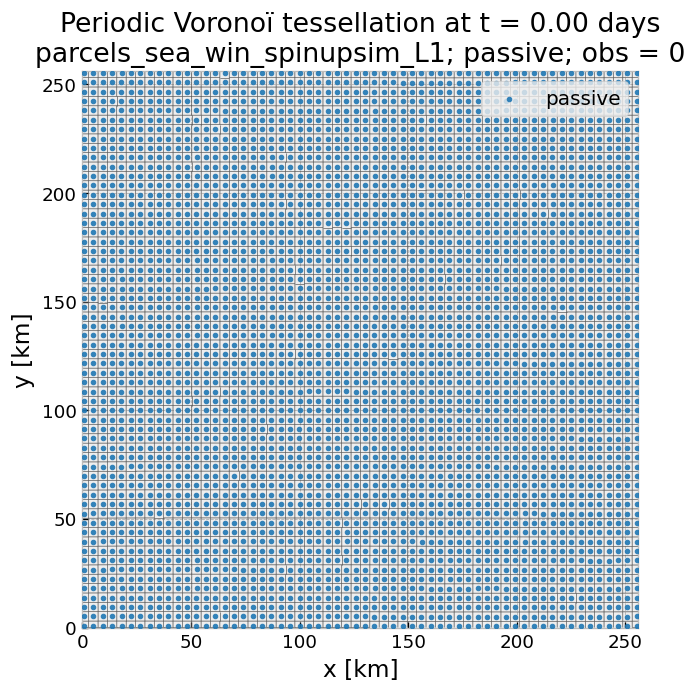

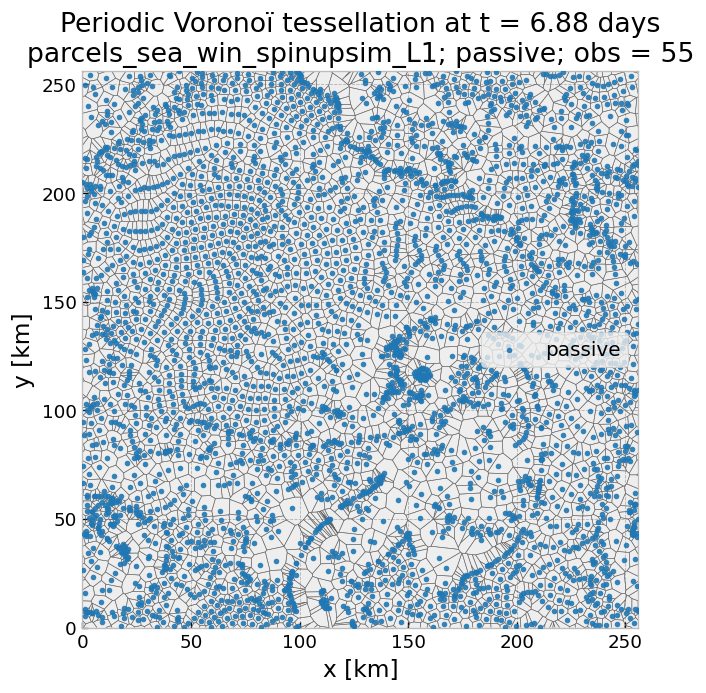

In [4]:
# ============================================================
# 17. VORONOÏ TESSELLATION SNAPSHOTS
# ============================================================

if COMPUTE_VORONOI:
    print("\nComputing Voronoï tessellation snapshots...")

    # Voronoï-specific settings live here, not at the top.
    PLOT_VORONOI_SNAPSHOTS = True
    SAVE_VORONOI_SUMMARY = True

    VORONOI_LINE_WIDTH = 0.35
    VORONOI_LINE_ALPHA = 0.75
    VORONOI_POINT_SIZE = 8
    VORONOI_POINT_ALPHA = 0.9

    VORONOI_DIR = CASE_RESULTS_DIR / "metrics" / "voronoi"
    VORONOI_FIG_DIR = CASE_RESULTS_DIR / "figures" / "voronoi_snapshots"

    if SAVE_VORONOI_SUMMARY:
        VORONOI_DIR.mkdir(parents=True, exist_ok=True)

    if SAVE_FIGURES and PLOT_VORONOI_SNAPSHOTS:
        VORONOI_FIG_DIR.mkdir(parents=True, exist_ok=True)

    domain = mclus.domain_from_parcels_dataset(ds_parcels)

    reference_ds = next(iter(trajectories.values()))["ds"]
    n_obs = reference_ds.sizes["obs"]

    voronoi_obs_indices = []

    for obs_selection in SNAPSHOT_OBS_SELECTIONS:
        obs_idx = resolve_obs_index(obs_selection, n_obs)

        if obs_idx < 0 or obs_idx >= n_obs:
            print(f"Skipping invalid Voronoï obs selection: {obs_selection}")
            continue

        voronoi_obs_indices.append(obs_idx)

    voronoi_obs_indices = sorted(set(voronoi_obs_indices))

    for particle_tag, item in trajectories.items():
        ds = item["ds"]
        label = item["label"]
        style = class_style_map[particle_tag]

        xname, yname = get_xy_names(ds)

        # ----------------------------------------------------
        # 17a. Compact Voronoï summary statistics
        # ----------------------------------------------------
        vor_summary = mclus.compute_voronoi_summary(
            ds_traj=ds,
            obs_indices=voronoi_obs_indices,
            domain=domain,
        )

        vor_summary.attrs.update({
            "case_name": case_name,
            "particle_tag": particle_tag,
            "particle_label": label,
            "level_tag": level_tag,
            "release_time_index": int(RELEASE_TIME_INDEX),
            "runtime_days": float(RUNTIME_DAYS),
        })

        print(f"\nVoronoï summary: {particle_tag}")
        print(vor_summary)

        if SAVE_VORONOI_SUMMARY:
            vor_path = VORONOI_DIR / (
                f"{particle_tag}_{level_tag}_"
                f"release_t{RELEASE_TIME_INDEX:04d}_voronoi_summary.nc"
            )
            vor_summary.to_netcdf(vor_path)
            print(f"  saved: {vor_path}")

        # ----------------------------------------------------
        # 17b. Voronoï snapshot plots
        # ----------------------------------------------------
        if PLOT_VORONOI_SNAPSHOTS:
            for obs_idx in voronoi_obs_indices:
                elapsed_days = get_elapsed_time_days(ds, obs_idx)

                x = ds[xname].isel(obs=obs_idx).values
                y = ds[yname].isel(obs=obs_idx).values

                result = mclus.periodic_voronoi_snapshot(
                    x=x,
                    y=y,
                    domain=domain,
                )

                fig, ax = plt.subplots(figsize=ptheme.FIGSIZE_MAP)

                mclus.plot_voronoi_snapshot(
                    ax=ax,
                    pieces=result["pieces"],
                    x=x,
                    y=y,
                    domain=domain,
                    line_color="0.35",
                    point_color=style["color"],
                    point_marker=style["marker"],
                    point_size=VORONOI_POINT_SIZE,
                    point_alpha=VORONOI_POINT_ALPHA,
                    line_width=VORONOI_LINE_WIDTH,
                    line_alpha=VORONOI_LINE_ALPHA,
                    km=True,
                    label=label,
                )

                ax.set_xlabel("x [km]")
                ax.set_ylabel("y [km]")
                ax.set_title(
                    f"Periodic Voronoï tessellation at t = {elapsed_days:.2f} days\n"
                    f"{RUN_TITLE_INFO}; {label}; obs = {obs_idx}"
                )
                ax.legend(loc="best")

                plt.tight_layout()

                savefig_if_enabled(
                    fig,
                    VORONOI_FIG_DIR / (
                        f"{particle_tag}_{level_tag}_"
                        f"release_t{RELEASE_TIME_INDEX:04d}_"
                        f"voronoi_obs{obs_idx:04d}.png"
                    ),
                    save=SAVE_FIGURES,
                )

                plt.show()

else:
    print("\nVoronoï computation skipped.")